# Plot CDS-level Metrics vs. Sequencing Error Rate

Compares F1, Precision, and Sensitivity across three sequencing error levels for all models.
Evaluated on test sets of a configurable read length (default: 300 bp).

**Three error levels compared:**
- typical:    5e-06 indel / 0.004 substitution rate
- high: 1.25e-05 indel / 0.01 substitution rate
- stress:   3.75e-05 indel / 0.03 substitution rate

**Four figure types per metric (F1, Precision, Sensitivity):**
1. Grouped bar chart (aggregated counts, per-genome min/max error bars)
2. Line/scatter chart (aggregated counts, one line per model)
3. Boxplot (per-genome distributions)
4. Precision vs. Sensitivity scatter (aggregated, error rate encoded as size)

In [35]:
import os
import pickle
import sys
from pathlib import Path

import matplotlib
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
matplotlib.rcParams['text.usetex'] = False
import numpy as np
import pandas as pd
from tqdm import tqdm

sys.path.insert(0, '..')
from plot_config import FONT_SIZES, MODEL_COLORS, MODEL_DISPLAY_NAMES, MODEL_MARKERS

plt.rcParams["figure.dpi"] = 300
plt.rcParams.update(FONT_SIZES)

## Configuration

In [36]:
# Read length to evaluate. Change to 75, 100, or 150 or 300 as needed.
READ_LENGTH: int = 300

# Error rate levels to compare on the x-axis.
ERROR_CONFIGS = [
    {
        "key": "typical",
        "indel": "5e-06",
        "sub": "0.004",
        "label": r"Typical (0.001\\% indel rate, $0.4\%$ substitution rate)",
        "short_label": "Typical",
    },
    {
        "key": "high",
        "indel": "1.25e-05",
        "sub": "0.01",
        "label": r"High (0.0025\\% indel rate, $1\%$ substitution rate)",
        "short_label": "High",
    },
    {
        "key": "stress",
        "indel": "3.75e-05",
        "sub": "0.03",
        "label": r"Stress (0.0075\\% indel rate, $3\%$ substitution rate)",
        "short_label": "Stress",
    },
]

# Models to evaluate (in display order).
MODEL_NAMES = [
    "fgs_complete",
    "fgs_illumina_5",
    "fgs_illumina_10",
    "prodigal",
    "deep_cds_no_errors",
    "deep_cds_substitution",
    "deep_cds_errors",
]

# IoU threshold for true-positive matching (must equal 1 for exact CDS match)
OVERLAP_CRITERIA: float = 1.0

# Translation-table-4 families excluded from the aggregated comparison
TT4_FAMILIES: set[str] = {"Mycoplasmataceae"}

## Paths

In [37]:
PROJECT_ROOT = Path("../../../..").resolve()
TESTSET_DIR = PROJECT_ROOT / "data/processed_data/testset_processed"
PREDS_BASE = PROJECT_ROOT / "data/processed_data/predictions/processed_predictions"
TEST_ACCESSIONS_FILE = (
    PROJECT_ROOT / "data/processed_data/genome_partitions/test_partition_accessions.txt"
)
GENOME_INFO_CSV = (
    PROJECT_ROOT / "data/processed_data/dataset_information/genomes_info_with_partitions.csv"
)

print(f"Project root: {PROJECT_ROOT}")

# Toggle: set True to load pre-computed results from disk (fast), False to run full data processing
LOAD_PROCESSED_DATA = True
_script_name = "plot_metrics_vs_error_rate"
_cache_dir = str(PROJECT_ROOT / "data" / "processed_data" / "report_results" / "with_errors" / _script_name / f"{READ_LENGTH}bp")

Project root: /Users/nrt204/Desktop/deep-cds


## Helper Functions

In [38]:
def _pred_path(accession: str, data_type: str, model: str) -> Path:
    paths = {
        "prodigal": PREDS_BASE / f"prodigal_preds/{data_type}/{accession}/model_preds_dict.pkl",
        "fgs_complete": PREDS_BASE / f"fgs_preds/{data_type}_complete/{accession}.pkl",
        "fgs_illumina_5": PREDS_BASE / f"fgs_preds/{data_type}_illumina_5/{accession}.pkl",
        "fgs_illumina_10": PREDS_BASE / f"fgs_preds/{data_type}_illumina_10/{accession}.pkl",
        "deep_cds_a1_no_errors": (
            PREDS_BASE
            / f"DeepCDS_A1/model_without_errors/{data_type}"
            / "esm2_8m_all_genomes_seed_42_trained_final_no_dropout"
            / accession
            / "model_preds_dict.pkl"
        ),
        "deep_cds_no_errors": (
            PREDS_BASE
            / f"DeepCDS/model_without_errors/{data_type}"
            / "full_model_all_genomes_seed_42_trained_final_8M_no_dropout"
            / accession
            / "model_preds_dict.pkl"
        ),
        "deep_cds_substitution": (
            PREDS_BASE
            / f"DeepCDS/model_with_substitution_errors/{data_type}"
            / "full_model_all_genomes_seed_42_trained_final_8M_no_dropout"
            / accession
            / "model_preds_dict.pkl"
        ),
        "deep_cds_errors": (
            PREDS_BASE
            / f"DeepCDS/model_with_errors/{data_type}"
            / "full_model_all_genomes_seed_42_trained_final_8M_no_dropout"
            / accession
            / "model_preds_dict.pkl"
        ),
    }
    return paths[model]

In [39]:
def get_full_cds(reads_dict: dict) -> dict:
    """Merge CDS fragments split by indel errors into full CDS entries."""
    for read in reads_dict:
        cds_fragments_connections = reads_dict[read]["cds_fragments_connection"]
        cds_coords = reads_dict[read]["cds_coords"]
        indices_to_remove = []
        for cds_frag_mapping in cds_fragments_connections:
            if len(cds_frag_mapping) > 1:
                if len(cds_fragments_connections) != cds_frag_mapping[0] + 1:
                    if len(cds_frag_mapping) == 1:
                        cds_frag_mapping = [i - 1 for i in cds_frag_mapping]
                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [0, 2]:
                    cds_frag_mapping = [0, 1]
                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [2, 3, 4]:
                    cds_frag_mapping = [0, 1, 2]
                start_frag = cds_coords[min(cds_frag_mapping)][0]
                end_frag = cds_coords[max(cds_frag_mapping)][1]
                indices_to_remove += cds_frag_mapping
                assert start_frag < end_frag
                cds_coords.append([start_frag, end_frag, "disrupted_rf"])
                reads_dict[read]["cds_coords"] = cds_coords
        for idx in sorted(indices_to_remove, reverse=True):
            cds_coords.pop(idx)
    return reads_dict


def calculate_iou(coord1, coord2) -> float:
    start1, stop1, rf1 = coord1
    start2, stop2, rf2 = coord2
    if rf1 != rf2:
        return 0.0
    inter_start = max(start1, start2)
    inter_stop = min(stop1, stop2)
    if inter_start >= inter_stop:
        return 0.0
    inter_len = inter_stop - inter_start
    union_len = max(stop1, stop2) - min(start1, start2)
    return inter_len / union_len if union_len > 0 else 0.0


def find_matching_genes(predicted_coords, actual_coords, overlap_criteria):
    matched_pairs = []
    used_actual: set = set()
    for pred_idx, pred_coord in enumerate(predicted_coords):
        best_iou = 0.0
        best_actual_idx = -1
        for actual_idx, actual_coord in enumerate(actual_coords):
            if actual_idx in used_actual:
                continue
            iou = calculate_iou(pred_coord, actual_coord)
            if iou >= overlap_criteria and iou > best_iou:
                best_iou = iou
                best_actual_idx = actual_idx
        if best_actual_idx != -1:
            matched_pairs.append((pred_idx, best_actual_idx))
            used_actual.add(best_actual_idx)
    return matched_pairs, len(matched_pairs)


def _metrics_from_counts(tp: int, predicted: int, actual: int) -> tuple[float, float, float]:
    """Return (precision, recall, f1) from raw counts."""
    precision = tp / predicted if predicted > 0 else 0.0
    recall = tp / actual if actual > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )
    return precision, recall, f1

## Data Loading & Metric Computation

In [40]:
def run_evaluation(
    read_length: int,
    error_configs: list[dict],
    model_names: list[str],
) -> tuple[dict, dict]:
    """Evaluate all models across all error levels for a given read length.

    TT4 genomes (Mycoplasmataceae) are excluded from aggregated metrics for a
    fair comparison.

    Returns:
        aggregated: {error_key: {model: {precision, recall, f1}}}
        per_genome: {error_key: {model: {precision: [], recall: [], f1: []}}}
    """
    test_accessions = [
        a.strip() for a in TEST_ACCESSIONS_FILE.read_text().splitlines() if a.strip()
    ]
    genome_info = pd.read_csv(GENOME_INFO_CSV).set_index("accession")
    tt4_accessions = {
        acc
        for acc in test_accessions
        if acc in genome_info.index and genome_info.loc[acc, "family"] in TT4_FAMILIES
    }
    print(f"Total test accessions: {len(test_accessions)}  (TT4 excluded: {len(tt4_accessions)})")

    aggregated: dict = {}
    per_genome: dict = {}

    for cfg in error_configs:
        key = cfg["key"]
        data_type = f"with_errors_{cfg['indel']}i_{cfg['sub']}s_{read_length}bp"
        print(f"\n=== {cfg['label']} ===")
        print(f"    data_type: {data_type}")

        agg_tp = {m: 0 for m in model_names}
        agg_pred = {m: 0 for m in model_names}
        agg_actual = {m: 0 for m in model_names}

        pg_prec: dict[str, list[float]] = {m: [] for m in model_names}
        pg_rec: dict[str, list[float]] = {m: [] for m in model_names}
        pg_f1: dict[str, list[float]] = {m: [] for m in model_names}

        for accession in tqdm(test_accessions, desc=cfg["short_label"].replace("\n", " ")):
            if accession in tt4_accessions:
                continue

            testset_pkl = TESTSET_DIR / data_type / accession / "testset_dict.pkl"
            read_names_pkl = TESTSET_DIR / data_type / accession / "read_names_list.pkl"

            if not testset_pkl.exists() or not read_names_pkl.exists():
                continue

            with open(testset_pkl, "rb") as fh:
                testset_dict = get_full_cds(pickle.load(fh))
            with open(read_names_pkl, "rb") as fh:
                read_names_list = pickle.load(fh)

            for model in model_names:
                pred_path = _pred_path(accession, data_type, model)
                if not pred_path.exists():
                    continue

                with open(pred_path, "rb") as fh:
                    preds_dict = get_full_cds(pickle.load(fh))

                tp_g = pred_g = actual_g = 0
                for read_name in read_names_list:
                    coords_test = testset_dict.get(read_name, {}).get("cds_coords", [])
                    coords_pred = preds_dict.get(read_name, {}).get("cds_coords", [])
                    _, tp = find_matching_genes(coords_pred, coords_test, OVERLAP_CRITERIA)
                    tp_g += tp
                    pred_g += len(coords_pred)
                    actual_g += len(coords_test)

                prec_g, rec_g, f1_g = _metrics_from_counts(tp_g, pred_g, actual_g)
                pg_prec[model].append(prec_g)
                pg_rec[model].append(rec_g)
                pg_f1[model].append(f1_g)

                agg_tp[model] += tp_g
                agg_pred[model] += pred_g
                agg_actual[model] += actual_g

        agg: dict = {}
        for model in model_names:
            if agg_pred[model] == 0 and agg_actual[model] == 0:
                agg[model] = {"precision": np.nan, "recall": np.nan, "f1": np.nan}
            else:
                prec, rec, f1 = _metrics_from_counts(
                    agg_tp[model], agg_pred[model], agg_actual[model]
                )
                agg[model] = {"precision": prec, "recall": rec, "f1": f1}
                print(
                    f"  {MODEL_DISPLAY_NAMES[model]:<28}"
                    f"  P={prec:.3f}  R={rec:.3f}  F1={f1:.3f}"
                )

        aggregated[key] = agg
        per_genome[key] = {
            model: {"precision": pg_prec[model], "recall": pg_rec[model], "f1": pg_f1[model]}
            for model in model_names
        }

    return aggregated, per_genome

In [41]:
import os

if not LOAD_PROCESSED_DATA:
    print(f"Evaluating {READ_LENGTH} bp test sets across sequencing error rates...")
    aggregated, per_genome = run_evaluation(READ_LENGTH, ERROR_CONFIGS, MODEL_NAMES)
else:

    print(f"Loading pre-computed results from:\n  {_cache_dir}")
    with open(os.path.join(_cache_dir, "aggregated.pkl"), "rb") as f:
        aggregated = pickle.load(f)
    with open(os.path.join(_cache_dir, "per_genome.pkl"), "rb") as f:
        per_genome = pickle.load(f)

Loading pre-computed results from:
  /Users/nrt204/Desktop/deep-cds/data/processed_data/report_results/with_errors/plot_metrics_vs_error_rate/300bp


In [42]:
if not LOAD_PROCESSED_DATA:
    os.makedirs(_cache_dir, exist_ok=True)
    _objects_to_save = {
        "aggregated": aggregated,
        "per_genome": per_genome,
    }
    for _name, _obj in _objects_to_save.items():
        with open(os.path.join(_cache_dir, f"{_name}.pkl"), "wb") as f:
            pickle.dump(_obj, f)
    print(f"Results saved to {_cache_dir}")

## Plotting

In [ ]:
_METRIC_YLABEL = {"f1": "F1 Score", "precision": "Precision", "recall": "Sensitivity"}

def _x_tick_labels(error_configs: list[dict]) -> list[str]:
    return [cfg["short_label"] for cfg in error_configs]


def _active_models(per_genome: dict, error_configs: list[dict], metric: str) -> list[str]:
    """Return only those models that have at least one data point."""
    return [
        m
        for m in MODEL_NAMES
        if any(per_genome[cfg["key"]][m][metric] for cfg in error_configs)
    ]

### Grouped Boxplots (per-genome distributions)

In [65]:
def plot_boxplots(
    per_genome: dict,
    error_configs: list[dict],
    model_names: list[str],
    read_length: int,
    metric: str,
) -> None:
    active = _active_models(per_genome, error_configs, metric)
    if not active:
        print(f"No per-genome data for boxplot ({metric}).")
        return

    n_active = len(active)
    x_pos = np.arange(len(error_configs))
    box_width = 0.8 / n_active
    offsets = (np.arange(n_active) - (n_active - 1) / 2) * box_width

    matplotlib.rcParams['text.usetex'] = False
    fig, ax = plt.subplots(figsize=(11, 8))

    for k, model in enumerate(active):
        color = MODEL_COLORS[model]
        positions, data = [], []
        for i, cfg in enumerate(error_configs):
            vals = per_genome[cfg["key"]][model][metric]
            if vals:
                positions.append(x_pos[i] + offsets[k])
                data.append(vals)
        if not data:
            continue

        bp = ax.boxplot(
            data,
            patch_artist=True,
            positions=positions,
            widths=box_width * 0.88,
            showfliers=True,
            flierprops=dict(
                marker="o",
                markersize=2.5,
                alpha=0.5,
                markerfacecolor=color,
                markeredgecolor=color,
            ),
            manage_ticks=False,
        )
        for patch in bp["boxes"]:
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        for line in bp["medians"]:
            line.set_color("black")
            line.set_linewidth(1.5)
        ax.plot([], [], color=color, linewidth=6, alpha=0.7, label=MODEL_DISPLAY_NAMES[model])

    # Horizontal gridlines every 0.1
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))

    ax.set_xticks(x_pos)
    ax.set_xticklabels(_x_tick_labels(error_configs))
    ax.set_xlabel("Sequencing Error Rate")
    ax.set_ylabel(_METRIC_YLABEL[metric])
    ax.set_ylim(0.35, 1.02)
    ax.set_title(f"{_METRIC_YLABEL[metric]} vs. Sequencing Error Rate for {read_length} bp read length", fontsize=16)
    ax.grid(True, alpha=0.3, axis="y")
    ax.legend(bbox_to_anchor=(0.5, -0.09), loc="upper center", ncol=4)

    plt.tight_layout()
    # plt.savefig(f"metrics_vs_error_rate_{metric}_{read_length}bp.svg", dpi=500, bbox_inches="tight")
    plt.show()

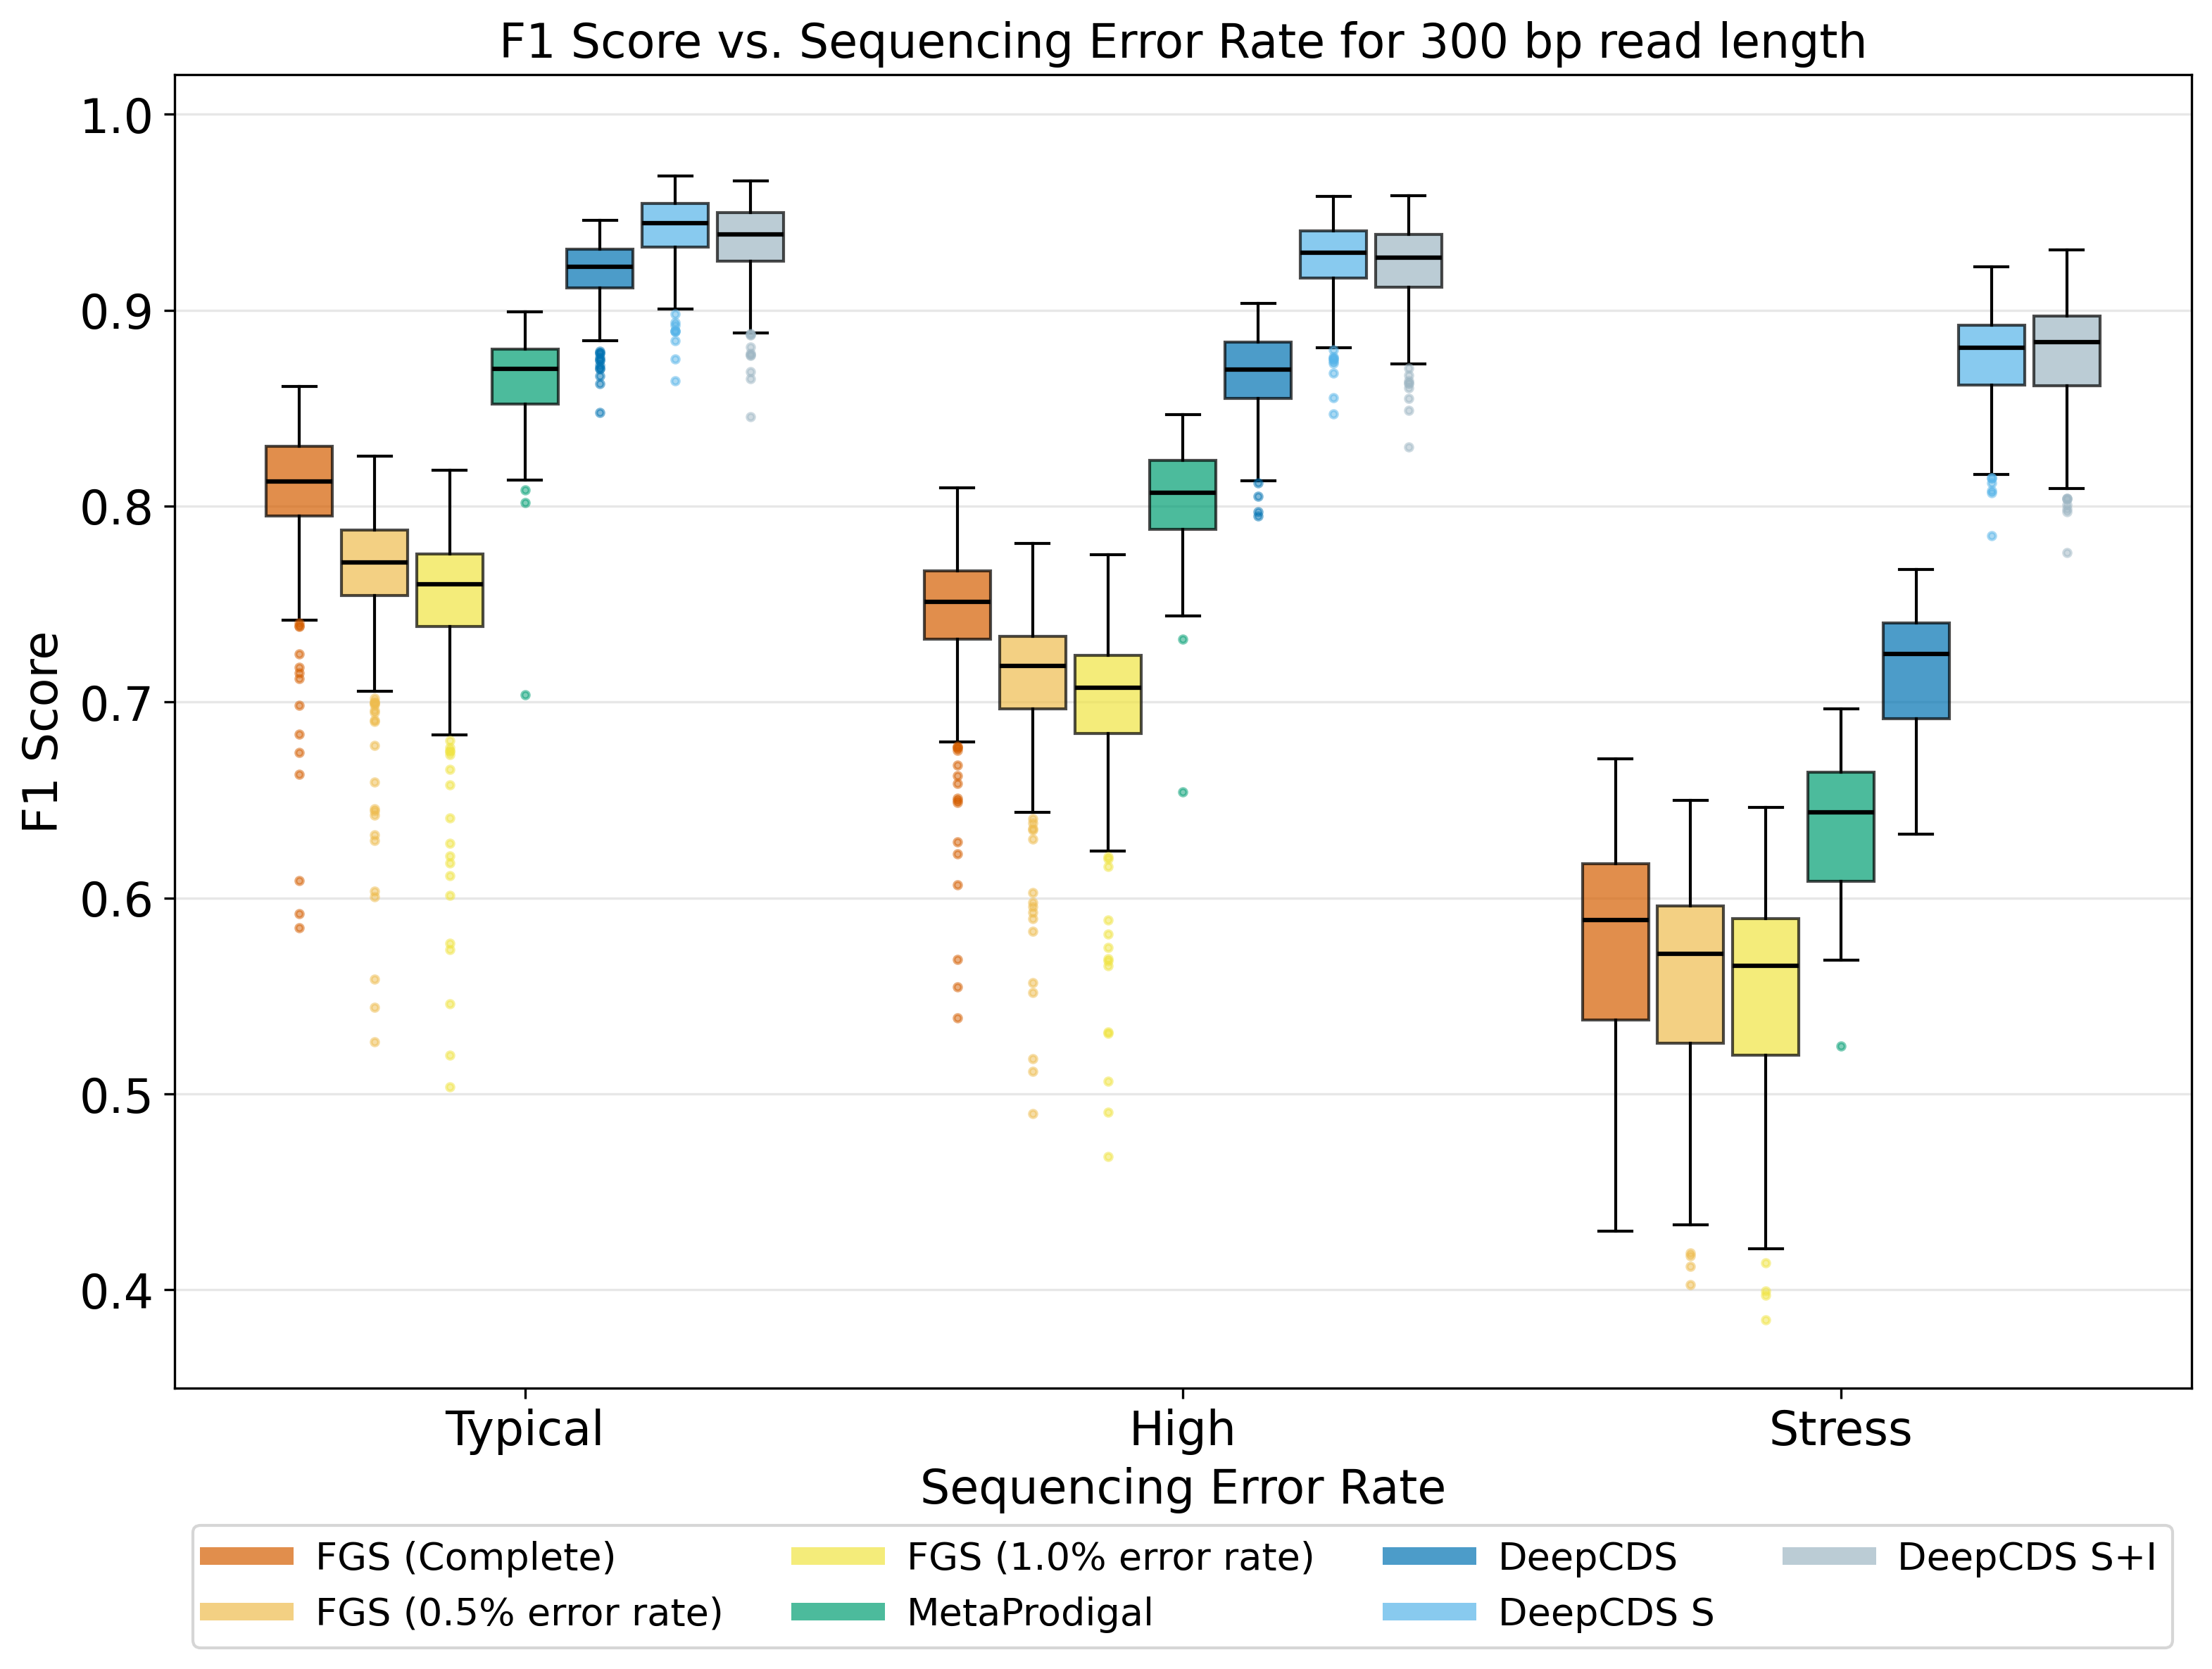

In [66]:
for metric in ["f1"]: #, "precision", "recall"]:
    plot_boxplots(per_genome, ERROR_CONFIGS, MODEL_NAMES, READ_LENGTH, metric)

### Boxplots by Model (one group per model, three boxes per error level)

In [50]:
# Colors for the three error levels
_ERROR_COLORS = {
    "typical":    "#4393c3",   # blue
    "high": "#f4a582",   # orange
    "stress":   "#d6604d",   # red
}

def plot_boxplots_by_model(
    per_genome: dict,
    error_configs: list[dict],
    model_names: list[str],
    read_length: int,
    metric: str,
) -> None:
    """Boxplot layout grouped by model.

    X-axis has one cluster per model. Within each cluster there are three
    side-by-side boxplots, one per error configuration (typical / high / stress).
    Box colour encodes error level; the legend shows error level only.
    """
    active = [m for m in model_names if any(
        per_genome[cfg["key"]][m][metric] for cfg in error_configs
    )]
    if not active:
        print(f"No per-genome data for {metric}.")
        return

    n_models = len(active)
    n_err = len(error_configs)
    box_width = 0.7 / n_err
    offsets = (np.arange(n_err) - (n_err - 1) / 2) * box_width
    x_centers = np.arange(n_models)

    matplotlib.rcParams['text.usetex'] = False
    fig, ax = plt.subplots(figsize=(max(14, n_models * 1.4), 8))

    for j, cfg in enumerate(error_configs):
        color = _ERROR_COLORS[cfg["key"]]
        positions, data = [], []
        for i, model in enumerate(active):
            vals = per_genome[cfg["key"]][model][metric]
            if vals:
                positions.append(x_centers[i] + offsets[j])
                data.append(vals)

        if not data:
            continue

        bp = ax.boxplot(
            data,
            patch_artist=True,
            positions=positions,
            widths=box_width * 0.88,
            showfliers=True,
            flierprops=dict(
                marker="o",
                markersize=2.5,
                alpha=0.5,
                markerfacecolor=color,
                markeredgecolor=color,
            ),
            manage_ticks=False,
        )
        for patch in bp["boxes"]:
            patch.set_facecolor(color)
            patch.set_alpha(0.75)
        for line in bp["medians"]:
            line.set_color("black")
            line.set_linewidth(1.5)

        # Legend proxy
        ax.plot([], [], color=color, linewidth=7, alpha=0.75, label=cfg["short_label"].replace("\n", " "))

    ax.set_xticks(x_centers)
    ax.set_xticklabels(
        [MODEL_DISPLAY_NAMES[m] for m in active],
        rotation=30,
        ha="right",
    )
    ax.set_ylabel(_METRIC_YLABEL[metric])
    ax.set_ylim(0, 1.05)

    # Horizontal gridlines every 0.1
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
    ax.grid(True, alpha=0.3, axis="y")

    # Vertical lines between model groups
    for i in range(n_models - 1):
        ax.axvline(x=x_centers[i] + 0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)

    # Legend outside the plot
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.07),
        borderaxespad=0,
        ncol=3
    )
    plt.tight_layout()
    # plt.savefig(f"metrics_vs_error_rate_boxplot_by_model_{metric}_{read_length}bp.svg", dpi=400)
    plt.show()

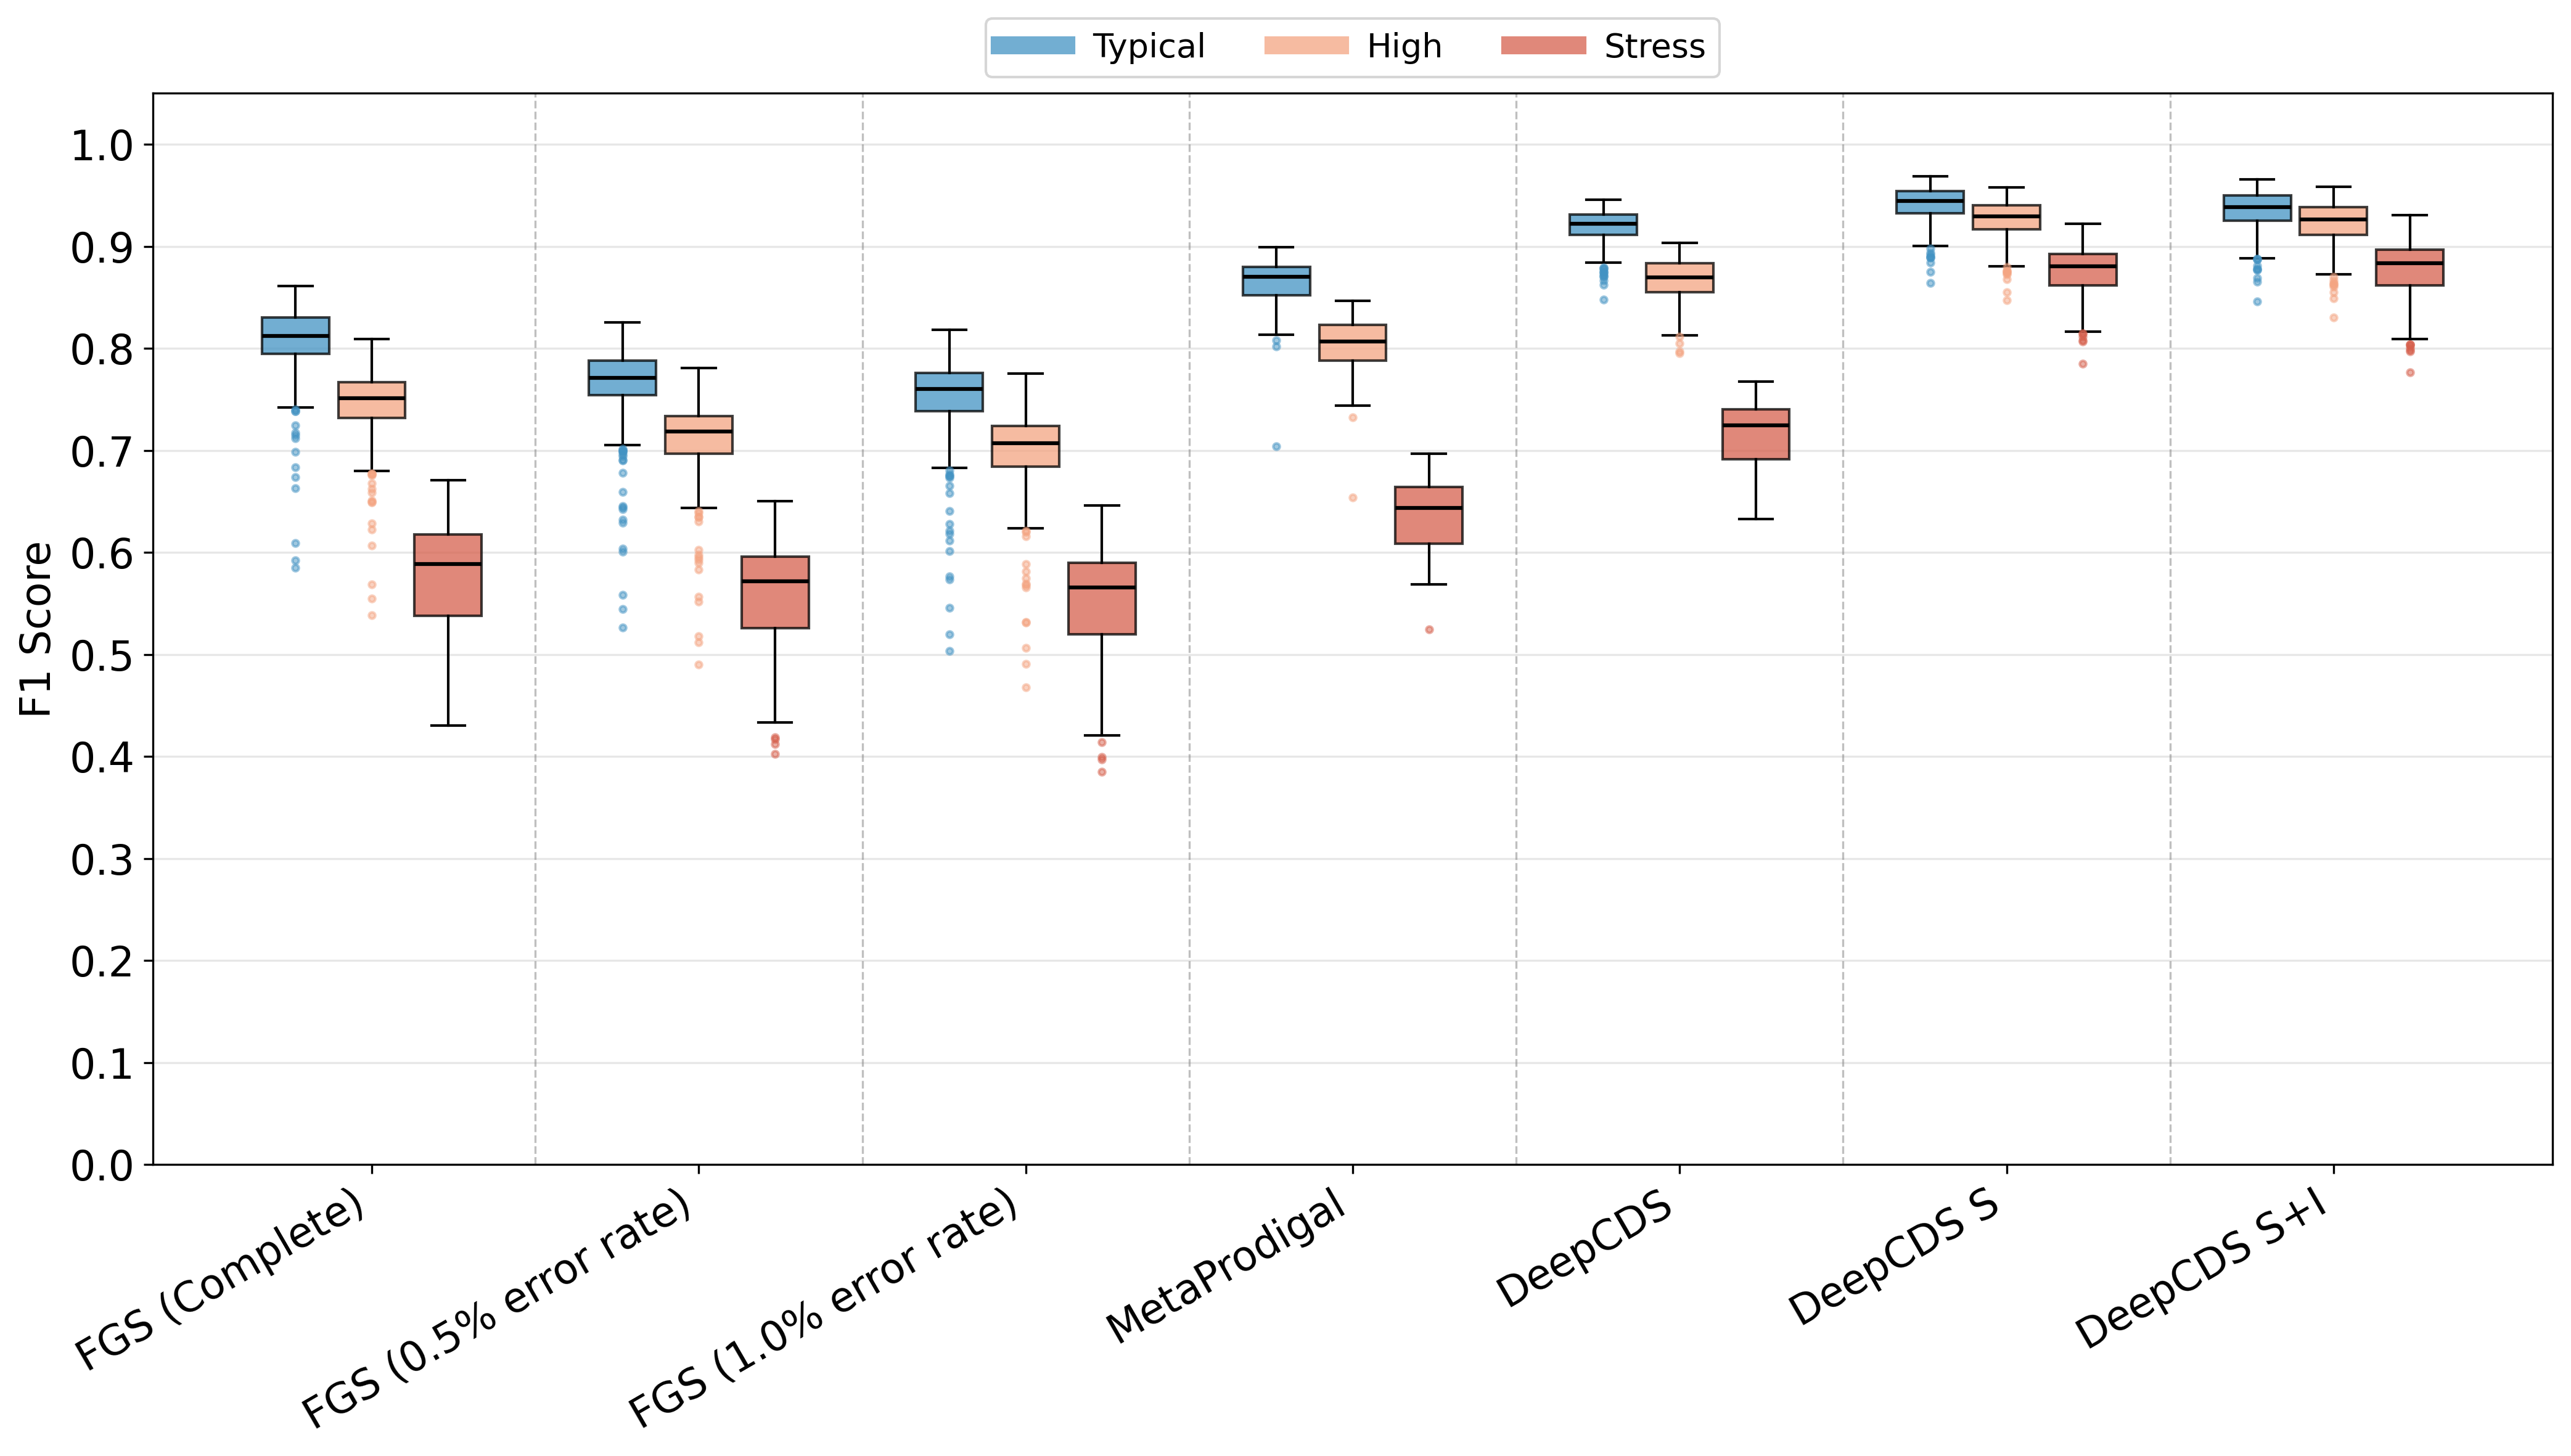

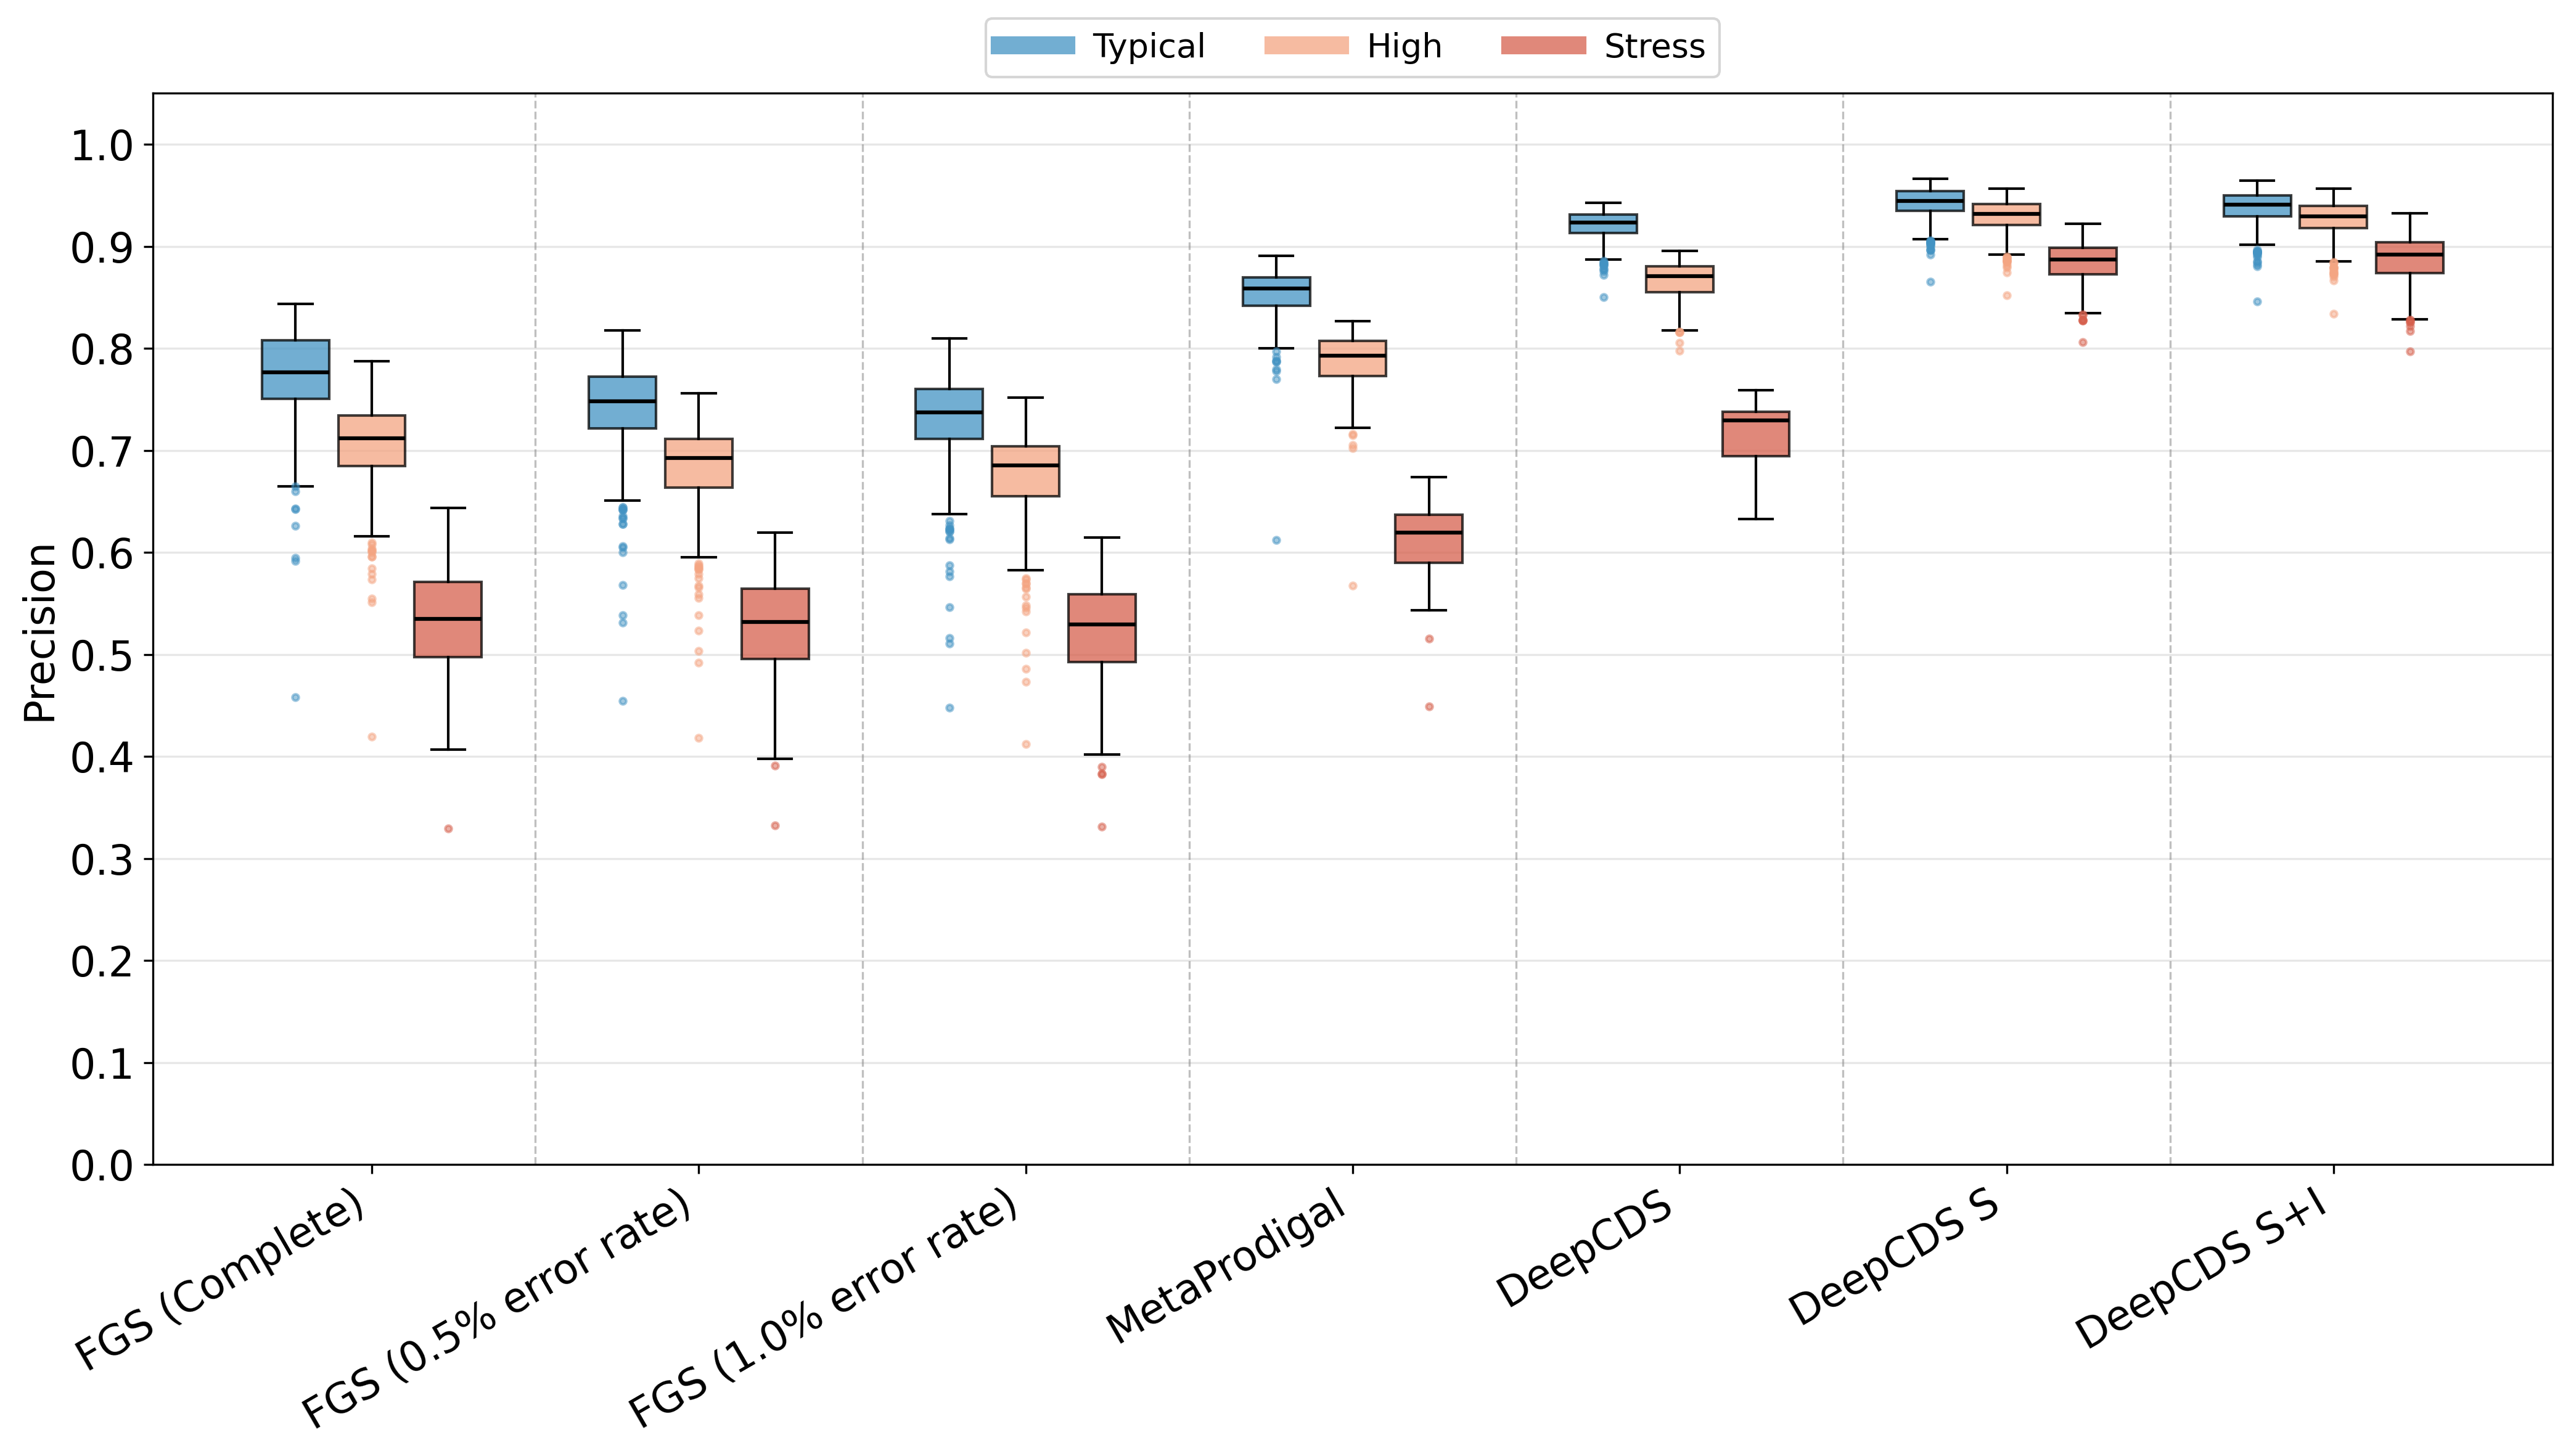

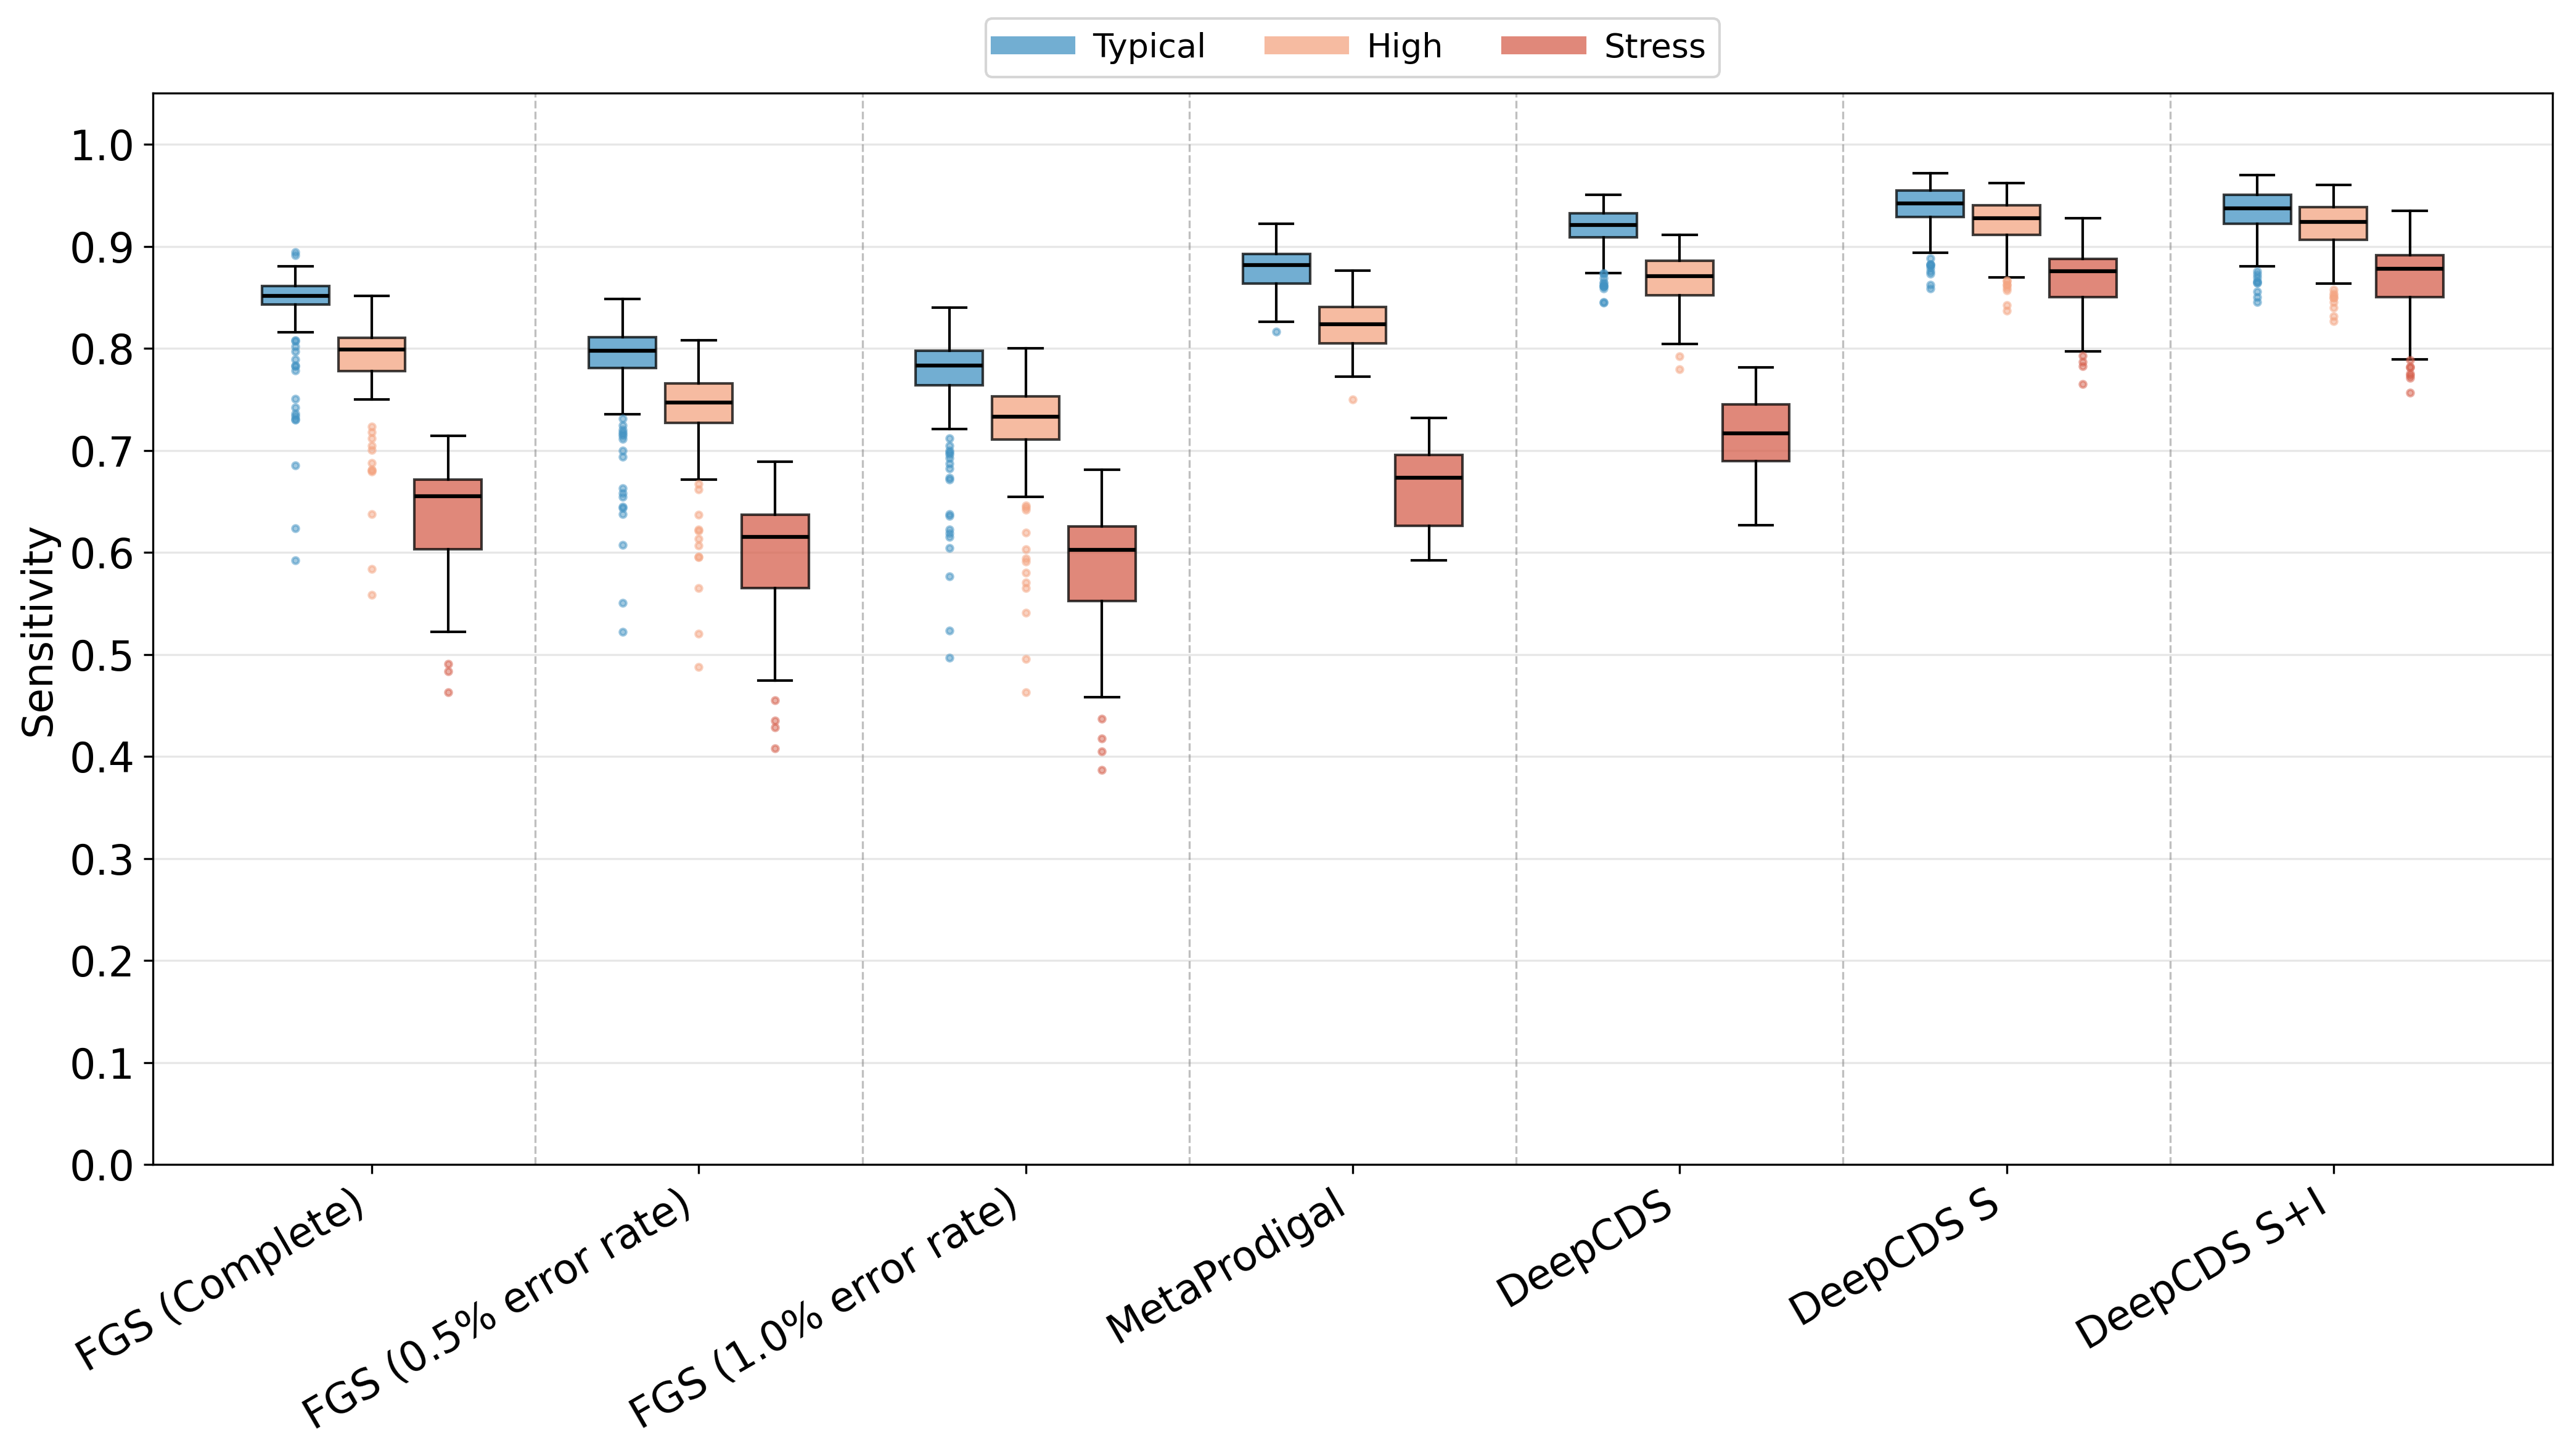

In [67]:
for metric in ["f1", "precision", "recall"]:
    plot_boxplots_by_model(per_genome, ERROR_CONFIGS, MODEL_NAMES, READ_LENGTH, metric)